# Plant Disease Classifier
## Step 5: Train the Model

**What you will learn in this notebook:**
- What is a Loss Function and why we need it
- What is an Optimizer and how it updates weights
- How one training epoch works step by step
- How the validation loop works
- How to save the best model automatically
- How to plot accuracy and loss curves

---


---
## Cell 1: Import Everything

In [1]:
import os
import sys
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

# Add src folder to path so we can import our modules
sys.path.append('../src')

from dataset import get_dataloaders
from model import build_model

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

# Create outputs folder
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../outputs/results', exist_ok=True)
print()
print('All imports successful.')

PyTorch version : 2.5.1+cu121
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU

All imports successful.


---
## Cell 2: What is a Loss Function?

A loss function measures **how wrong** the model is.

```
Model predicts : Healthy=30%,  Diseased=70%
True label     : Healthy (1.0, 0.0)
Loss           : HIGH  (model was wrong)

Model predicts : Healthy=95%,  Diseased=5%
True label     : Healthy (1.0, 0.0)
Loss           : LOW   (model was right)
```

We use **CrossEntropyLoss** which is standard for classification tasks.
The goal of training is to minimize this loss over time.

In [2]:
# Demonstrate loss function
criterion = nn.CrossEntropyLoss()

# Example 1: Model is very WRONG
wrong_prediction = torch.tensor([[0.1, 0.9]])   # predicts 90% diseased
true_label       = torch.tensor([0])             # but true label is healthy (0)
loss_wrong = criterion(wrong_prediction, true_label)

# Example 2: Model is very RIGHT
right_prediction = torch.tensor([[0.9, 0.1]])   # predicts 90% healthy
loss_right = criterion(right_prediction, true_label)

print('Loss Function Demonstration:')
print('-----------------------------')
print(f'When model is WRONG : loss = {loss_wrong.item():.4f}  (high)')
print(f'When model is RIGHT : loss = {loss_right.item():.4f}  (low)')
print()
print('Training goal: make loss as small as possible.')

Loss Function Demonstration:
-----------------------------
When model is WRONG : loss = 1.1711  (high)
When model is RIGHT : loss = 0.3711  (low)

Training goal: make loss as small as possible.


---
## Cell 3: What is an Optimizer?

The optimizer uses the loss to **update the model weights**.

```
Training loop (one batch):

  1. Feed images through model        (forward pass)
  2. Calculate loss                   (how wrong was it?)
  3. Calculate gradients              (backpropagation)
  4. Update weights using optimizer   (learn from mistake)
  5. Repeat for next batch
```

We use **Adam** optimizer - it is the most popular choice.
Learning rate controls how big each weight update step is.

```
Large learning rate  : learns fast but may overshoot
Small learning rate  : learns slow but more stable
0.001 is a good default starting point
```

In [3]:
# Build model
model = build_model(num_classes=2, device=device)

# Only pass TRAINABLE parameters to optimizer
# No point updating frozen layers
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001       # learning rate
)

# Loss function
criterion = nn.CrossEntropyLoss()

# Learning rate scheduler: reduce LR by 0.1 every 5 epochs
# This helps fine-tune in later epochs
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

print('Optimizer  : Adam')
print('Loss       : CrossEntropyLoss')
print('LR         : 0.001')
print('Scheduler  : StepLR (reduce by 0.1 every 5 epochs)')
print()
print('Ready to train.')

Optimizer  : Adam
Loss       : CrossEntropyLoss
LR         : 0.001
Scheduler  : StepLR (reduce by 0.1 every 5 epochs)

Ready to train.


---
## Cell 4: Load the Data

In [4]:
DATA_DIR   = '../data/PlantVillage'
BATCH_SIZE = 32

train_loader, val_loader, test_loader, class_names = get_dataloaders(
    data_dir   = DATA_DIR,
    batch_size = BATCH_SIZE
)

print()
print(f'Classes     : {len(class_names)}')
print(f'Train batch : {len(train_loader)} batches x {BATCH_SIZE} images')
print(f'Val batch   : {len(val_loader)} batches x {BATCH_SIZE} images')

Train: 14,446 | Val: 3,096 | Test: 3,096

Classes     : 15
Train batch : 452 batches x 32 images
Val batch   : 97 batches x 32 images


---
## Cell 5: Training and Validation Functions

We define two functions:
- `train_one_epoch()` : runs through all training batches once
- `validate()` : checks model performance on validation set

Key difference:
```
Training   : model.train()  gradients ON   weights get updated
Validation : model.eval()   gradients OFF  weights stay the same
```

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Runs one full pass through the training data.
    Returns average loss and accuracy for this epoch.
    """
    model.train()        # set model to training mode

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(loader):

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Step 1: Clear old gradients
        optimizer.zero_grad()

        # Step 2: Forward pass
        outputs = model(images)              # shape: [32, 2]

        # Step 3: Calculate loss
        loss = criterion(outputs, labels)

        # Step 4: Backward pass (calculate gradients)
        loss.backward()

        # Step 5: Update weights
        optimizer.step()

        # Track metrics
        total_loss    += loss.item() * images.size(0)
        predicted      = outputs.argmax(dim=1)    # pick class with highest score
        correct       += (predicted == labels).sum().item()
        total_samples += images.size(0)

        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f'  Batch {batch_idx+1}/{len(loader)}  '
                  f'Loss: {loss.item():.4f}  '
                  f'Acc: {correct/total_samples*100:.1f}%')

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy


def validate(model, loader, criterion, device):
    """
    Evaluates model on validation set.
    No weight updates happen here.
    """
    model.eval()         # set model to evaluation mode

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    with torch.no_grad():    # no gradients needed for validation
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs    = model(images)
            loss       = criterion(outputs, labels)

            total_loss    += loss.item() * images.size(0)
            predicted      = outputs.argmax(dim=1)
            correct       += (predicted == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy


print('train_one_epoch() defined.')
print('validate() defined.')
print()
print('Ready to start training loop.')

train_one_epoch() defined.
validate() defined.

Ready to start training loop.


---
## Cell 6: The Training Loop

This is where actual learning happens.

```
For each epoch:
    1. Train on all 14,446 training images
    2. Validate on all 3,096 validation images
    3. If validation accuracy improved, save the model
    4. Print results
```

We run for 10 epochs. With your RTX 4050 each epoch should take about 1-2 minutes.

In [6]:
NUM_EPOCHS   = 10
best_val_acc = 0.0
MODEL_PATH   = '../outputs/best_model.pth'

# Store history for plotting later
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : []
}

print(f'Starting training for {NUM_EPOCHS} epochs...')
print(f'Model will be saved to: {MODEL_PATH}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    print('-' * 40)

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )

    # Step the scheduler
    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        saved = '  --> saved best model'
    else:
        saved = ''

    print(f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%')
    print(f'Val Loss  : {val_loss:.4f}  Val Acc  : {val_acc:.2f}%{saved}')

print()
print('=' * 60)
print(f'Training complete.')
print(f'Best validation accuracy: {best_val_acc:.2f}%')
print(f'Best model saved to     : {MODEL_PATH}')

Starting training for 10 epochs...
Model will be saved to: ../outputs/best_model.pth

Epoch 1/10
----------------------------------------
  Batch 100/452  Loss: 0.0642  Acc: 94.2%
  Batch 200/452  Loss: 0.1040  Acc: 94.8%
  Batch 300/452  Loss: 0.0266  Acc: 95.8%
  Batch 400/452  Loss: 0.0207  Acc: 96.2%
Train Loss: 0.0942  Train Acc: 96.45%
Val Loss  : 0.0366  Val Acc  : 98.58%  --> saved best model

Epoch 2/10
----------------------------------------
  Batch 100/452  Loss: 0.0182  Acc: 98.2%
  Batch 200/452  Loss: 0.0386  Acc: 98.4%
  Batch 300/452  Loss: 0.0310  Acc: 98.4%
  Batch 400/452  Loss: 0.0021  Acc: 98.5%
Train Loss: 0.0416  Train Acc: 98.51%
Val Loss  : 0.0235  Val Acc  : 99.19%  --> saved best model

Epoch 3/10
----------------------------------------
  Batch 100/452  Loss: 0.0480  Acc: 98.8%
  Batch 200/452  Loss: 0.1148  Acc: 98.8%
  Batch 300/452  Loss: 0.0085  Acc: 98.8%
  Batch 400/452  Loss: 0.0064  Acc: 98.8%
Train Loss: 0.0347  Train Acc: 98.75%
Val Loss  : 0.0287

---
## Cell 7: Plot Training Curves

Visualize how loss and accuracy changed over epochs.
This helps us understand if the model learned well.

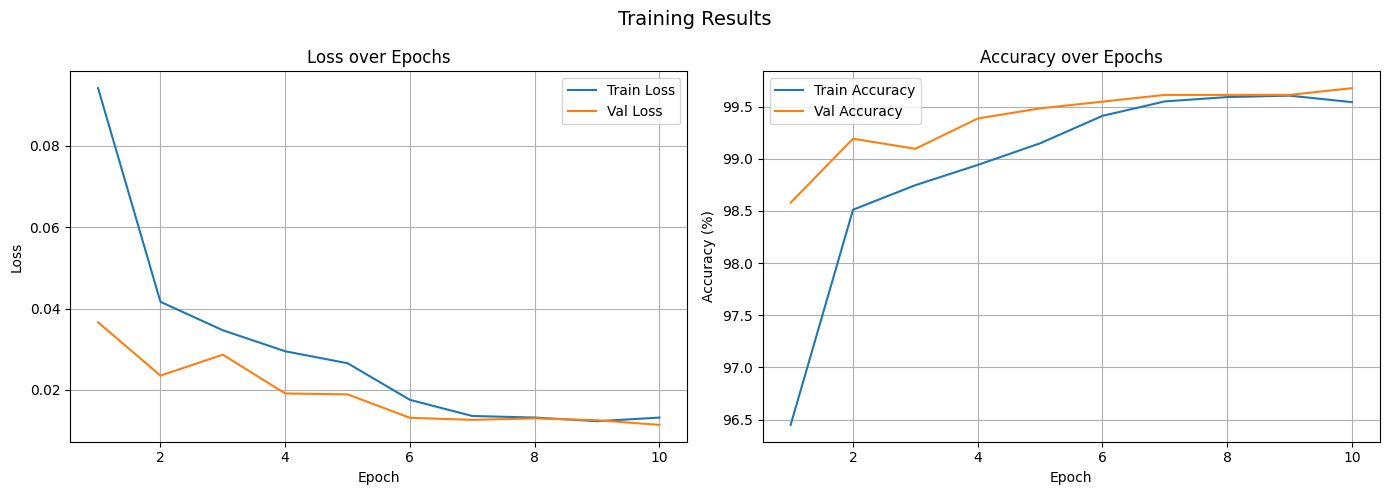

Plot saved to ../outputs/results/accuracy_plot.png


In [7]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Results', fontsize=14)

# Loss plot
axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(epochs, history['train_acc'], label='Train Accuracy')
axes[1].plot(epochs, history['val_acc'],   label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/results/accuracy_plot.png', dpi=150)
plt.show()

print('Plot saved to ../outputs/results/accuracy_plot.png')

---
## Cell 8: Save Training Code as src/train.py

In [8]:
train_code = '''
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total_samples = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * images.size(0)
        correct       += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)
    return total_loss / total_samples, correct / total_samples * 100


def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total_samples = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            total_loss    += loss.item() * images.size(0)
            correct       += (outputs.argmax(dim=1) == labels).sum().item()
            total_samples += images.size(0)
    return total_loss / total_samples, correct / total_samples * 100


def get_optimizer(model, lr=0.001):
    return Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)


def get_scheduler(optimizer):
    return StepLR(optimizer, step_size=5, gamma=0.1)
'''

with open('../src/train.py', 'w') as f:
    f.write(train_code)

print('src/train.py saved successfully.')
print()
print('Step 5 Complete!')
print('Next: Step 6 - Evaluate and Test the Model')

src/train.py saved successfully.

Step 5 Complete!
Next: Step 6 - Evaluate and Test the Model


---
## Step 5 Summary

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| Loss function | Measures how wrong the model is | Training goal is to minimize this |
| CrossEntropyLoss | Standard loss for classification | Works well with softmax output |
| Optimizer | Updates model weights using loss | Adam is the most popular choice |
| Learning rate | Size of each weight update step | Too high = unstable, too low = slow |
| Epoch | One full pass through training data | More epochs = more learning |
| model.train() | Enables dropout and gradients | Must be set during training |
| model.eval() | Disables dropout and gradients | Must be set during validation |
| torch.no_grad() | Skips gradient calculation | Saves memory during validation |
| best model saving | Save weights when val acc improves | Keeps the best version of the model |

---
